In [18]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Feature engineering environment ready")

Feature engineering environment ready


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PS_20174392719_1491204439457_log.csv"
)

print("Dataset exists:", DATA_PATH.exists())
print("Dataset:", DATA_PATH)

Dataset exists: True
Dataset: /Users/binodkumar/Documents/financial-fraud-risk-intelligence/data/raw/PS_20174392719_1491204439457_log.csv


In [3]:
TARGET = "isFraud"

print("Model target:", TARGET)

Model target: isFraud


In [4]:
feature_query = f"""
SELECT
    step,
    type,
    amount,

    nameOrig,
    nameDest,

    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,

    isFlaggedFraud,

    isFraud,

    -- Balance movement
    oldbalanceOrg - newbalanceOrig
        AS origin_balance_change,

    newbalanceDest - oldbalanceDest
        AS destination_balance_change,

    -- Transaction amount relative to origin balance
    CASE
        WHEN oldbalanceOrg > 0
        THEN amount / oldbalanceOrg
        ELSE 0
    END
        AS amount_to_origin_balance_ratio,

    -- Whether origin account ends at zero
    CASE
        WHEN newbalanceOrig = 0
        THEN 1
        ELSE 0
    END
        AS origin_balance_zero_flag,

    -- Whether transaction exceeds recorded origin balance
    CASE
        WHEN amount > oldbalanceOrg
        THEN 1
        ELSE 0
    END
        AS amount_exceeds_origin_balance

FROM read_csv_auto('{DATA_PATH}')
"""

In [5]:
features = duckdb.sql(feature_query).df()

print("Rows:", f"{len(features):,}")
print("Columns:", len(features.columns))

features.head()

Rows: 6,362,620
Columns: 16


,step,type,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud,origin_balance_change,destination_balance_change,amount_to_origin_balance_ratio,origin_balance_zero_flag,amount_exceeds_origin_balance
0,1,PAYMENT,9839.64,C1231006815,M1979787155,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0,0.057834,0,0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0,0.087735,0,0
2,1,TRANSFER,181.00,C1305486145,C553264065,181.0,0.00,0.0,0.0,0,1,181.00,0.0,1.000000,1,0
3,1,CASH_OUT,181.00,C840083671,C38997010,181.0,0.00,21182.0,0.0,0,1,181.00,-21182.0,1.000000,1,0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0,0.280795,0,0


In [6]:
engineered_columns = [
    "origin_balance_change",
    "destination_balance_change",
    "amount_to_origin_balance_ratio",
    "origin_balance_zero_flag",
    "amount_exceeds_origin_balance"
]

features[engineered_columns].describe()

,origin_balance_change,destination_balance_change,amount_to_origin_balance_ratio,origin_balance_zero_flag,amount_exceeds_origin_balance
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,-2.123056e+04,1.242947e+05,8.171346e+01,5.673081e-01,6.411007e-01
std,1.466433e+05,8.129391e+05,3.395705e+03,4.954489e-01,4.796776e-01
min,-1.915268e+06,-1.306083e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,7.681118e-02,1.000000e+00,1.000000e+00
75%,1.015044e+04,1.491054e+05,2.219448e+00,1.000000e+00,1.000000e+00
max,1.000000e+07,1.056878e+08,3.925476e+06,1.000000e+00,1.000000e+00


In [7]:
features[engineered_columns].isna().sum()

origin_balance_change             0
destination_balance_change        0
amount_to_origin_balance_ratio    0
origin_balance_zero_flag          0
amount_exceeds_origin_balance     0
dtype: int64

In [9]:
features[TARGET].value_counts()

features[TARGET].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [10]:
# Inspect the temporal distribution before splitting

time_distribution = duckdb.sql(f"""
    SELECT
        MIN(step) AS min_step,
        MAX(step) AS max_step,
        COUNT(DISTINCT step) AS unique_steps
    FROM read_csv_auto('{DATA_PATH}')
""").df()

time_distribution

,min_step,max_step,unique_steps
0,1,743,743


In [11]:
# Identify approximate time-based split boundaries

step_quantiles = duckdb.sql(f"""
    SELECT
        QUANTILE_CONT(step, 0.70) AS train_end,
        QUANTILE_CONT(step, 0.85) AS validation_end,
        QUANTILE_CONT(step, 0.95) AS ninety_five_pct_step
    FROM read_csv_auto('{DATA_PATH}')
""").df()

step_quantiles

,train_end,validation_end,ninety_five_pct_step
0,323.0,378.0,490.0


In [12]:
# Temporal split

train_end = step_quantiles.loc[0, "train_end"]
validation_end = step_quantiles.loc[0, "validation_end"]

train = features[features["step"] <= train_end].copy()

validation = features[
    (features["step"] > train_end) &
    (features["step"] <= validation_end)
].copy()

test = features[
    features["step"] > validation_end
].copy()

print("Train rows:", f"{len(train):,}")
print("Validation rows:", f"{len(validation):,}")
print("Test rows:", f"{len(test):,}")

Train rows: 4,463,587
Validation rows: 980,416
Test rows: 918,617


In [13]:
# Verify temporal boundaries

print("Train step range:",
      train["step"].min(),
      "→",
      train["step"].max())

print("Validation step range:",
      validation["step"].min(),
      "→",
      validation["step"].max())

print("Test step range:",
      test["step"].min(),
      "→",
      test["step"].max())

Train step range: 1 → 323
Validation step range: 324 → 378
Test step range: 379 → 743


In [14]:
# Fraud rate across temporal splits

split_summary = pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "rows": [
        len(train),
        len(validation),
        len(test)
    ],
    "fraud_count": [
        train["isFraud"].sum(),
        validation["isFraud"].sum(),
        test["isFraud"].sum()
    ]
})

split_summary["fraud_rate_pct"] = (
    split_summary["fraud_count"]
    / split_summary["rows"]
    * 100
).round(4)

split_summary

,dataset,rows,fraud_count,fraud_rate_pct
0,Train,4463587,3643,0.0816
1,Validation,980416,564,0.0575
2,Test,918617,4006,0.4361


In [15]:
# Fraud prevalence across time

fraud_by_step = duckdb.sql(f"""
    SELECT
        step,
        COUNT(*) AS transactions,
        SUM(isFraud) AS fraud_transactions,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS fraud_rate_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY step
    ORDER BY step
""").df()

fraud_by_step.head()

,step,transactions,fraud_transactions,fraud_rate_pct
0,1,2708,16.0,0.5908
1,2,1014,8.0,0.7890
2,3,552,4.0,0.7246
3,4,565,10.0,1.7699
4,5,665,6.0,0.9023


In [16]:
# Compare fraud prevalence by broader time windows

fraud_by_window = duckdb.sql(f"""
    SELECT
        FLOOR(step / 50) AS time_window,
        COUNT(*) AS transactions,
        SUM(isFraud) AS fraud_transactions,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS fraud_rate_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY time_window
    ORDER BY time_window
""").df()

fraud_by_window

,time_window,transactions,fraud_transactions,fraud_rate_pct
0,0.0,1030257,584.0,0.0567
1,1.0,29253,600.0,2.0511
2,2.0,451844,512.0,0.1133
3,3.0,870820,550.0,0.0632
4,4.0,834264,573.0,0.0687
5,5.0,826036,574.0,0.0695
6,6.0,873196,494.0,0.0566
7,7.0,840450,574.0,0.0683
8,8.0,258581,580.0,0.2243
9,9.0,40998,516.0,1.2586


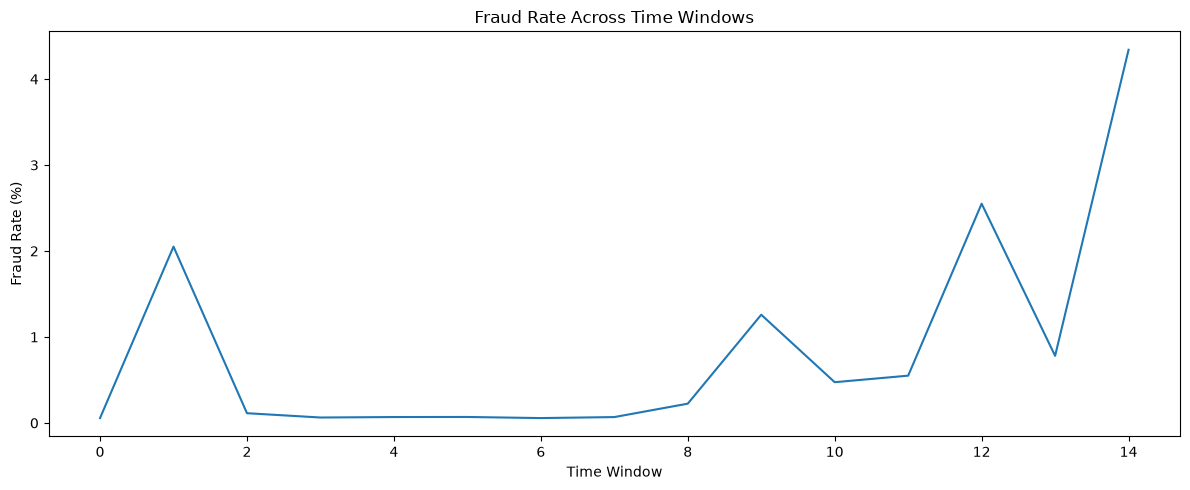

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_window["time_window"],
    fraud_by_window["fraud_rate_pct"]
)

plt.title("Fraud Rate Across Time Windows")
plt.xlabel("Time Window")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [20]:
print("Train:")
print(train["step"].min(), "→", train["step"].max())

print("\nValidation:")
print(validation["step"].min(), "→", validation["step"].max())

print("\nTest:")
print(test["step"].min(), "→", test["step"].max())

Train:
1 → 323

Validation:
324 → 378

Test:
379 → 743


In [21]:
# Inspect the feature set before modeling

print("Feature columns:")
for i, col in enumerate(features.columns, start=1):
    print(f"{i}. {col}")

print("\nTotal columns:", len(features.columns))

Feature columns:
1. step
2. type
3. amount
4. nameOrig
5. nameDest
6. oldbalanceOrg
7. newbalanceOrig
8. oldbalanceDest
9. newbalanceDest
10. isFlaggedFraud
11. isFraud
12. origin_balance_change
13. destination_balance_change
14. amount_to_origin_balance_ratio
15. origin_balance_zero_flag
16. amount_exceeds_origin_balance

Total columns: 16


In [22]:
# Separate target variable from predictors

TARGET = "isFraud"

X = features.drop(columns=[TARGET])
y = features[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (6362620, 15)
y shape: (6362620,)

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [23]:
# Inspect the existing fraud flag

print("isFlaggedFraud distribution:")
print(features["isFlaggedFraud"].value_counts())

print("\nFraud rate when isFlaggedFraud = 0:")
print(
    features.loc[features["isFlaggedFraud"] == 0, "isFraud"].mean()
)

print("\nFraud rate when isFlaggedFraud = 1:")
print(
    features.loc[features["isFlaggedFraud"] == 1, "isFraud"].mean()
)

isFlaggedFraud distribution:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Fraud rate when isFlaggedFraud = 0:
0.0012883090005287143

Fraud rate when isFlaggedFraud = 1:
1.0


In [24]:
# Create model-ready X and y for each temporal split

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_validation = validation.drop(columns=[TARGET])
y_validation = validation[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4463587, 15)
y_train: (4463587,)
X_validation: (980416, 15)
y_validation: (980416,)
X_test: (918617, 15)
y_test: (918617,)


In [25]:
# Define features for the primary fraud prediction model

EXCLUDED_COLUMNS = [
    "isFraud",
    "isFlaggedFraud"
]

MODEL_FEATURES = [
    col for col in features.columns
    if col not in EXCLUDED_COLUMNS
]

print("Primary model features:")
for i, col in enumerate(MODEL_FEATURES, start=1):
    print(f"{i}. {col}")

print("\nTotal model features:", len(MODEL_FEATURES))

Primary model features:
1. step
2. type
3. amount
4. nameOrig
5. nameDest
6. oldbalanceOrg
7. newbalanceOrig
8. oldbalanceDest
9. newbalanceDest
10. origin_balance_change
11. destination_balance_change
12. amount_to_origin_balance_ratio
13. origin_balance_zero_flag
14. amount_exceeds_origin_balance

Total model features: 14


In [26]:
# Build final model-ready datasets

X_train = train[MODEL_FEATURES].copy()
y_train = train["isFraud"].copy()

X_validation = validation[MODEL_FEATURES].copy()
y_validation = validation["isFraud"].copy()

X_test = test[MODEL_FEATURES].copy()
y_test = test["isFraud"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4463587, 14)
y_train: (4463587,)
X_validation: (980416, 14)
y_validation: (980416,)
X_test: (918617, 14)
y_test: (918617,)


In [27]:
# Check feature data types

print(X_train.dtypes)

print("\nNon-numeric columns:")
print(
    X_train.select_dtypes(exclude="number").columns.tolist()
)

step                                int64
type                                  str
amount                            float64
nameOrig                              str
nameDest                              str
oldbalanceOrg                     float64
newbalanceOrig                    float64
oldbalanceDest                    float64
newbalanceDest                    float64
origin_balance_change             float64
destination_balance_change        float64
amount_to_origin_balance_ratio    float64
origin_balance_zero_flag            int32
amount_exceeds_origin_balance       int32
dtype: object

Non-numeric columns:
['type', 'nameOrig', 'nameDest']


In [28]:
# Check for infinite values

print(
    "Infinite values in X_train:",
    np.isinf(X_train.select_dtypes(include="number")).sum().sum()
)

print(
    "Infinite values in X_validation:",
    np.isinf(X_validation.select_dtypes(include="number")).sum().sum()
)

print(
    "Infinite values in X_test:",
    np.isinf(X_test.select_dtypes(include="number")).sum().sum()
)

Infinite values in X_train: 0
Infinite values in X_validation: 0
Infinite values in X_test: 0


In [29]:
# Check duplicate transactions

print("Duplicate rows in training data:", train.duplicated().sum())
print("Duplicate rows in validation data:", validation.duplicated().sum())
print("Duplicate rows in test data:", test.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in validation data: 0
Duplicate rows in test data: 0


In [30]:
# Save model-ready datasets for the modeling notebook

train.to_parquet(
    "../data/processed/train_features.parquet",
    index=False
)

validation.to_parquet(
    "../data/processed/validation_features.parquet",
    index=False
)

test.to_parquet(
    "../data/processed/test_features.parquet",
    index=False
)

print("Model-ready datasets saved successfully.")

Model-ready datasets saved successfully.
